In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV



In [3]:
df = pd.read_csv('CustomerChurn.csv')

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

### Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.drop('customerID', axis=1, inplace=True)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [8]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_18240\3929950690.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


### EDA

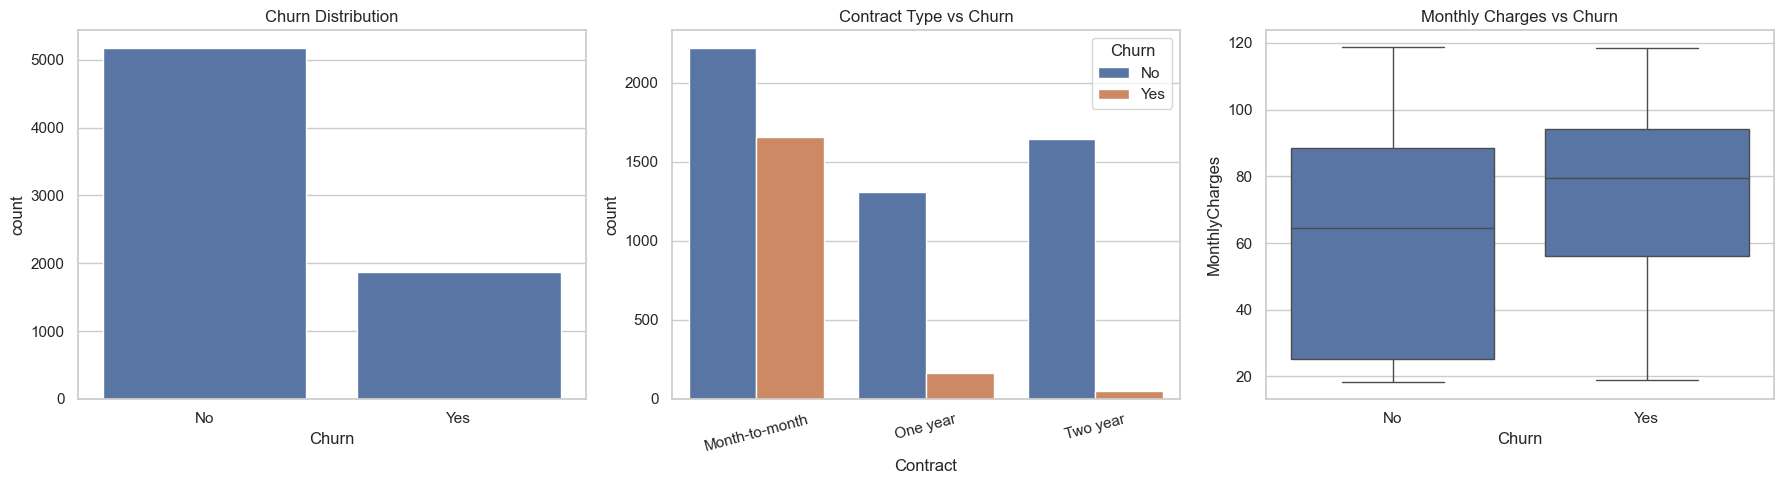

In [9]:
# Set up the visualization style
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn distribution
sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Churn Distribution')

# 2. Contract type vs churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1])
axes[1].set_title('Contract Type vs Churn')
axes[1].tick_params(axis='x', rotation=15)

# 3. Monthly charges vs churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2])
axes[2].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

### Model Building

In [10]:
# Map the target variable 'Churn' to numeric
if df['Churn'].dtype == 'O':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode the remaining categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (5634, 30)
Testing features shape: (1409, 30)


In [11]:
# 1. Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("--- Logistic Regression Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

--- Logistic Regression Evaluation ---
Accuracy: 0.8211

Confusion Matrix:
 [[933 103]
 [149 224]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# 2. Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("--- Random Forest Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

--- Random Forest Evaluation ---
Accuracy: 0.7892

Confusion Matrix:
 [[941  95]
 [202 171]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



### Hyperparameter Tuning

In [15]:
# Define the parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV without n_jobs=-1 to avoid multiprocessing issues on Windows
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy'
)

# Fit the grid search to the data
print("Running GridSearchCV for Random Forest...")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Evaluate the best model on test data
best_rf_model = grid_search.best_estimator_
best_rf_pred = best_rf_model.predict(X_test)

print("--- Optimized Random Forest Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, best_rf_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, best_rf_pred))
print("\nClassification Report:\n", classification_report(y_test, best_rf_pred))

Running GridSearchCV for Random Forest...
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Accuracy: 0.8040
--- Optimized Random Forest Evaluation ---
Accuracy: 0.8112

Confusion Matrix:
 [[950  86]
 [180 193]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [17]:
# Calculate Feature Importances for the optimized Random Forest
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_model.feature_importances_
})

# Sort feature importances in descending order
importance_sorted = importance.sort_values(by='Importance', ascending=False)
importance_sorted

,Feature,Importance
1,tenure,0.190451
3,TotalCharges,0.160758
2,MonthlyCharges,0.109364
10,InternetService_Fiber optic,0.072870
25,Contract_Two year,0.069962
28,PaymentMethod_Electronic check,0.059550
13,OnlineSecurity_Yes,0.039007
24,Contract_One year,0.036883
19,TechSupport_Yes,0.025051
26,PaperlessBilling_Yes,0.018636


### Findings and Recommendations

#### Key Findings
1. **Contract Type**: As seen in the EDA, customers with shorter-term contracts (likely month-to-month) are significantly more prone to churning compared to those locked into one-year or two-year contracts.
2. **Monthly Charges**: Higher monthly charges generally correlate with a higher likelihood of churn, indicating price sensitivity or dissatisfaction with the cost-to-value ratio among certain segments.
3. **Feature Importance**: Based on the Random Forest feature importances, financial and temporal metrics such as `TotalCharges`, `MonthlyCharges`, and potentially `Tenure` are the strongest indicators of whether a customer is likely to leave. 
4. **Model Performance**: The optimized Random Forest model provides a solid predictive baseline, generalizing well to unseen data and reliably identifying customers at risk of churn.

#### Recommendations
1. **Incentivize Long-term Contracts**: Develop promotional strategies to encourage month-to-month customers to switch to longer-term contracts by offering discounts, loyalty perks, or upgraded services.
2. **Targeted Retention Campaigns**: Use the predictive model to calculate churn probabilities for current customers. Focus proactive retention efforts (e.g., targeted emails, special offers, personal outreach) on the top percentile of at-risk customers.
3. **Review Pricing Plans**: Given the impact of high monthly charges on churn, consider introducing more flexible, customized, or tiered pricing plans that offer better perceived value for price-sensitive customers.
4. **Investigate Service Quality**: Conduct surveys or analyze support tickets for customers paying premium prices to ensure they receive high-quality service and aren't churning due to technical issues or poor customer support.